In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("mabel.txt", header=None, on_bad_lines='skip')

In [3]:
df.head()

,0,1
0,05/12/19,1:42 pm - Messages to this chat and calls are...
1,05/12/19,1:42 pm - Mabel Infoziant: Hi this is Mabel w...
2,05/12/19,1:42 pm - Mabel Infoziant: What’s your full name
3,05/12/19,1:42 pm - AR❤: Ramisha Rani K
4,05/12/19,1:42 pm - Mabel Infoziant: Ok


In [4]:
df.columns = ['Date','Chat']

In [5]:
df.head()

,Date,Chat
0,05/12/19,1:42 pm - Messages to this chat and calls are...
1,05/12/19,1:42 pm - Mabel Infoziant: Hi this is Mabel w...
2,05/12/19,1:42 pm - Mabel Infoziant: What’s your full name
3,05/12/19,1:42 pm - AR❤: Ramisha Rani K
4,05/12/19,1:42 pm - Mabel Infoziant: Ok


In [6]:
df=df.drop(0)

In [7]:
df.head()

,Date,Chat
1,05/12/19,1:42 pm - Mabel Infoziant: Hi this is Mabel w...
2,05/12/19,1:42 pm - Mabel Infoziant: What’s your full name
3,05/12/19,1:42 pm - AR❤: Ramisha Rani K
4,05/12/19,1:42 pm - Mabel Infoziant: Ok
5,05/12/19,1:42 pm - Mabel Infoziant: ramisharanik@gmail...


In [9]:
message = df['Chat'].str.split('-', n=1, expand=True)

In [10]:
message.head()

,0,1
1,1:42 pm,Mabel Infoziant: Hi this is Mabel we just spoke
2,1:42 pm,Mabel Infoziant: What’s your full name
3,1:42 pm,AR❤: Ramisha Rani K
4,1:42 pm,Mabel Infoziant: Ok
5,1:42 pm,Mabel Infoziant: ramisharanik@gmail.com


In [11]:
df["Time"] = message[0]

In [12]:
df.head()

,Date,Chat,Time
1,05/12/19,1:42 pm - Mabel Infoziant: Hi this is Mabel w...,1:42 pm
2,05/12/19,1:42 pm - Mabel Infoziant: What’s your full name,1:42 pm
3,05/12/19,1:42 pm - AR❤: Ramisha Rani K,1:42 pm
4,05/12/19,1:42 pm - Mabel Infoziant: Ok,1:42 pm
5,05/12/19,1:42 pm - Mabel Infoziant: ramisharanik@gmail...,1:42 pm


In [13]:
message1 = message[1].str.split(':',n=1,expand=True)

In [14]:
message1.head()

,0,1
1,Mabel Infoziant,Hi this is Mabel we just spoke
2,Mabel Infoziant,What’s your full name
3,AR❤,Ramisha Rani K
4,Mabel Infoziant,Ok
5,Mabel Infoziant,ramisharanik@gmail.com


In [15]:
df["Name"]=message1[0]

In [16]:
df["Chat"]=message1[1]

In [18]:
df=df[["Date","Time","Name","Chat"]]

In [19]:
df.head()

,Date,Time,Name,Chat
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K
4,05/12/19,1:42 pm,Mabel Infoziant,Ok
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 1 to 50
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    50 non-null     object
 1   Time    50 non-null     object
 2   Name    50 non-null     object
 3   Chat    50 non-null     object
dtypes: object(4)
memory usage: 1.7+ KB



# Sentiment Analysis

In [25]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\pripo\AppData\Roaming\nltk_data...


True

In [26]:
from nltk.sentiment import SentimentIntensityAnalyzer

In [27]:
sid = SentimentIntensityAnalyzer()

In [29]:
sid.polarity_scores

<bound method SentimentIntensityAnalyzer.polarity_scores of <nltk.sentiment.vader.SentimentIntensityAnalyzer object at 0x000002B5CC203D90>>

In [30]:
senti = sid.polarity_scores(df['Chat'][1])

In [31]:
senti

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

In [34]:
import warnings
warnings.filterwarnings('ignore')

In [35]:
df['Scores']=df['Chat'].apply(lambda txt:sid.polarity_scores(txt))

In [41]:
df['Negative']=df['Scores'].apply(lambda scores:scores['neg'])
df['Neutral']=df['Scores'].apply(lambda scores:scores['neu'])
df['Positive']=df['Scores'].apply(lambda scores:scores['pos'])
df['Compound']=df['Scores'].apply(lambda scores:scores['compound'])
df['comp_score'] = df['Compound'].apply(lambda c: 'pos' if c >=0 else 'neg')

In [42]:
df.head()

,Date,Time,Name,Chat,Scores,Negative,Neutral,Positive,Compound,comp_score
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0,1.0,0.0,0.000,pos
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0,1.0,0.0,0.000,pos
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0,1.0,0.0,0.000,pos
4,05/12/19,1:42 pm,Mabel Infoziant,Ok,"{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound...",0.0,0.0,1.0,0.296,pos
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0,1.0,0.0,0.000,pos


In [44]:
df['comp_score'].value_counts()

comp_score
pos    48
neg     2
Name: count, dtype: int64



# Topic Modelling

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_df=0.95,min_df=2,stop_words='english')
dtm=tfidf.fit_transform(df["Chat"])

In [52]:
from sklearn.decomposition import NMF
nmf_model=NMF(n_components=5,random_state=42)
nmf_model.fit(dtm)

,n_components,5
,init,None
,solver,'cd'
,beta_loss,'frobenius'
,tol,0.0001
,max_iter,200
,random_state,42
,alpha_W,0.0
,alpha_H,'same'
,l1_ratio,0.0
,verbose,0


In [58]:
for index,topic in enumerate(nmf_model.components_):
    results=([tfidf.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print(results)
    #print(index)
    #print(topic)

['share', 'soon', 'ask', 'yes', 'sure', 'abstract', 'read', 'kk', 'yeah', 'mam']
['students', 'start', 'yes', 'think', 'sure', 'just', 'send', 'tomorrow', 'mam', 'ok']
['details', 'abstracts', 'start', 'students', 'phone', 'ask', 'office', 'number', 'vignesh', 'send']
['share', 'soon', 'yes', 'mam', 'office', 'know', 'just', 'tomorrow', 'church', 'hi']
['phone', 'know', 'sure', 'share', 'soon', 'meeting', 'details', 'yes', 'need', 'ramisha']


In [59]:
topic_results=nmf_model.transform(dtm)
df["Topic"]=topic_results.argmax(axis=1)

In [62]:
df

,Date,Time,Name,Chat,Scores,Negative,Neutral,Positive,Compound,comp_score,Topic
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.000,1.000,0.000,0.0000,pos,3
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.000,1.000,0.000,0.0000,pos,0
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.000,1.000,0.000,0.0000,pos,4
4,05/12/19,1:42 pm,Mabel Infoziant,Ok,"{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound...",0.000,0.000,1.000,0.2960,pos,1
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.000,1.000,0.000,0.0000,pos,0
6,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.000,1.000,0.000,0.0000,pos,0
7,05/12/19,1:43 pm,AR❤,Yes Mam,"{'neg': 0.0, 'neu': 0.27, 'pos': 0.73, 'compou...",0.000,0.270,0.730,0.4019,pos,4
8,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.000,1.000,0.000,0.0000,pos,2
9,05/12/19,1:43 pm,AR❤,Yeah mam,"{'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'comp...",0.000,0.312,0.688,0.2960,pos,0
10,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.000,1.000,0.000,0.0000,pos,0




# World Cloud

In [64]:
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
import matplotlib.pyplot as plt
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pripo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [65]:
dataset = df

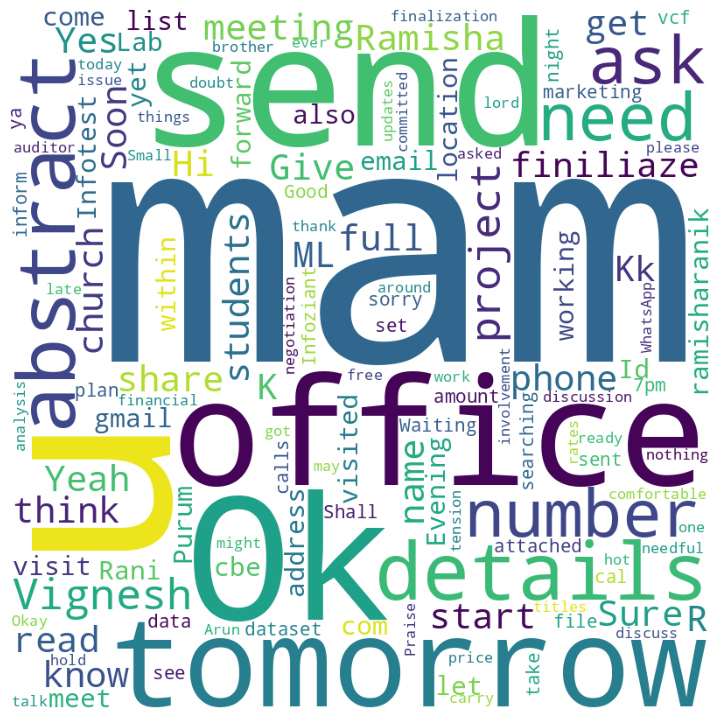

Successfully created


In [66]:
comment_words = []
stoplist = stopwords.words('english')
stoplist.extend(['omitted', 'voice','missed','call','video','deleted','media','message'])
wordcloudss="This function saves image"
dataset.index=range(dataset.shape[0])
for i in range(1,len(dataset)): 
    comment_words.append(dataset['Chat'][i])
    vv=" ".join(comment_words)          
    wordcloud = WordCloud(width = 800, height = 800, 
                                background_color ='white', 
                                      stopwords = stoplist, 
                                      min_font_size = 10).generate(vv)   
plt.figure(figsize = (9, 7), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.savefig('wordcloud.PNG')
plt.show() 
print("Successfully created")
wordcloudss="This function saves image"